In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import welch, butter, sosfiltfilt, hilbert

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
files = {
    'Healthy': {
        'path': '../data/Normal_1.mat',
        'var':  'X098_DE_time',
        'rpm':  1772,
    },
    'Inner Race': {
        'path': '../data/IR007_1.mat',
        'var':  'X106_DE_time',
        'rpm':  1772,
    },
    'Ball': {
        'path': '../data/B007_1.mat',
        'var':  'X119_DE_time',
        'rpm':  1772,
    },
    'Outer Race': {
        'path': '../data/OR007@6_1.mat',
        'var':  'X131_DE_time',
        'rpm':  1772,
    },
}

fs = 12000  # Hz, sampling frequency for drive-end channel

In [3]:
signals = {}
for condition, info in files.items():
    mat = loadmat(info['path'])
    signals[condition] = mat[info['var']].flatten()

In [4]:
bearing_6205 = {
    'name': 'SKF 6205-2RS JEM',
    'n_balls': 9,
    'ball_diameter_in': 0.3126,
    'pitch_diameter_in': 1.537,
    'contact_angle_deg': 0.0,
    'source': 'https://engineering.case.edu/bearingdatacenter/bearing-information',
}

In [5]:
def bearing_fault_frequencies(rpm, bearing):
    """
    Compute characteristic bearing fault frequencies.

    Parameters
    ----------
    rpm : float
        Shaft speed in revolutions per minute
    bearing : dict
        Bearing geometry with keys 'n_balls', 'ball_diameter_in',
        'pitch_diameter_in', 'contact_angle_deg'

    Returns
    -------
    dict
        Frequencies in Hz: 'f_shaft', 'BPFI', 'BPFO', 'BSF', 'FTF'
    """
    f_r = rpm / 60.0
    n = bearing['n_balls']
    d = bearing['ball_diameter_in']
    D = bearing['pitch_diameter_in']
    alpha = np.radians(bearing['contact_angle_deg'])

    ratio = (d / D) * np.cos(alpha)

    return {
        'f_shaft': f_r,
        'BPFI': (n / 2) * f_r * (1 + ratio),
        'BPFO': (n / 2) * f_r * (1 - ratio),
        'BSF':  (D / d) * f_r * (1 - ratio**2),
        'FTF':  (f_r / 2) * (1 - ratio),
    }

In [6]:
fault_freqs = bearing_fault_frequencies(1772, bearing_6205)

# Display as a clean table
df_freqs = pd.DataFrame({
    'Frequency (Hz)': fault_freqs,
}).round(2)
df_freqs.index.name = 'Component'
df_freqs

,Frequency (Hz)
Component,
f_shaft,29.53
BPFI,159.93
BPFO,105.87
BSF,139.20
FTF,11.76


In [16]:
overlay_freqs = {
    'Healthy': {
        'f_shaft': fault_freqs['f_shaft'],
    },
    'Inner Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFI':    fault_freqs['BPFI'],
        '2×BPFI':  2 * fault_freqs['BPFI'],
        '3×BPFI':  3 * fault_freqs['BPFI'],
    },
    'Ball': {
        'f_shaft': fault_freqs['f_shaft'],
        'FTF':     fault_freqs['FTF'],
        'BSF':     fault_freqs['BSF'],
        '2×BSF':   2 * fault_freqs['BSF'],
    },
    'Outer Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFO':    fault_freqs['BPFO'],
        '2×BPFO':  2 * fault_freqs['BPFO'],
        '3×BPFO':  3 * fault_freqs['BPFO'],
        '4×BPFO':  4 * fault_freqs['BPFO'],
    },
}

In [7]:
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    """
    Apply a zero-phase Butterworth bandpass filter.

    Parameters
    ----------
    signal : ndarray
        1D time-series signal
    fs : float
        Sampling frequency in Hz
    lowcut, highcut : float
        Lower and upper passband edges in Hz
    order : int
        Filter order. Default 4 is standard for vibration work.

    Returns
    -------
    filtered : ndarray
        Bandpass-filtered signal with zero phase distortion
    """
    nyq = fs / 2
    sos = butter(order, [lowcut/nyq, highcut/nyq], btype='band', output='sos')
    return sosfiltfilt(sos, signal)

In [8]:
filtered_signals = {}
for condition, signal in signals.items():
    filtered_signals[condition] = bandpass_filter(signal, fs, lowcut=2500, highcut=4000)

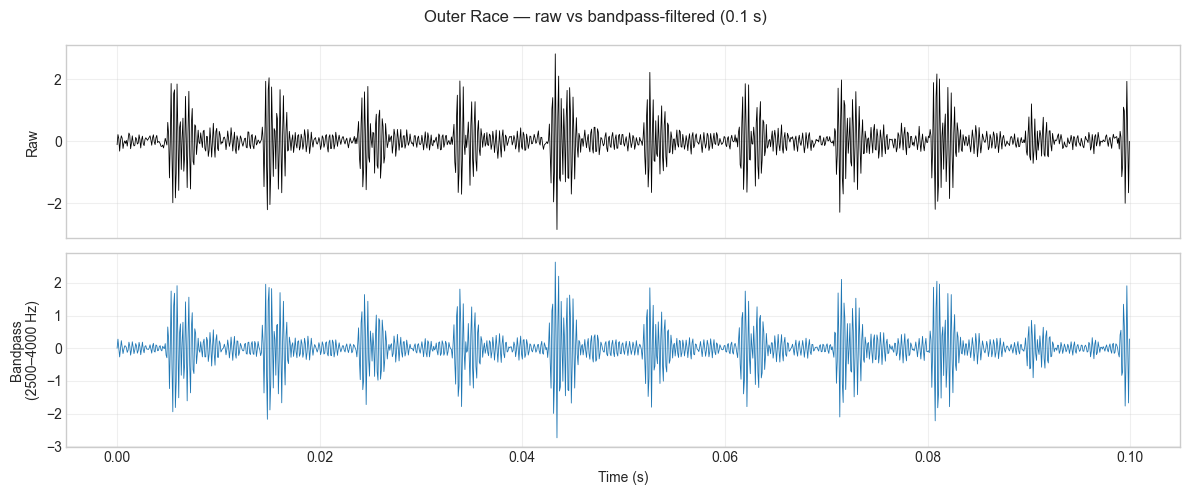

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

t = np.arange(int(0.1 * fs)) / fs  # first 0.1 seconds

condition = 'Outer Race'
raw = signals[condition][:len(t)]
filtered = filtered_signals[condition][:len(t)]

axes[0].plot(t, raw, linewidth=0.6, color='black')
axes[0].set_ylabel('Raw')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, filtered, linewidth=0.6, color='tab:blue')
axes[1].set_ylabel('Bandpass\n(2500–4000 Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'{condition} — raw vs bandpass-filtered (0.1 s)', fontsize=12)
fig.tight_layout()
plt.show()

In [10]:
def compute_envelope(signal):
    """
    Compute the amplitude envelope of a signal via the Hilbert transform.

    The Hilbert transform constructs an analytic signal whose magnitude
    is the instantaneous amplitude envelope of the input.

    Parameters
    ----------
    signal : ndarray
        Real-valued 1D signal, typically bandpass-filtered around a
        carrier frequency before this function is applied.

    Returns
    -------
    envelope : ndarray
        Amplitude envelope, same length as input
    """
    analytic = hilbert(signal)
    return np.abs(analytic)

In [11]:
envelopes = {}
for condition, filtered in filtered_signals.items():
    envelopes[condition] = compute_envelope(filtered)

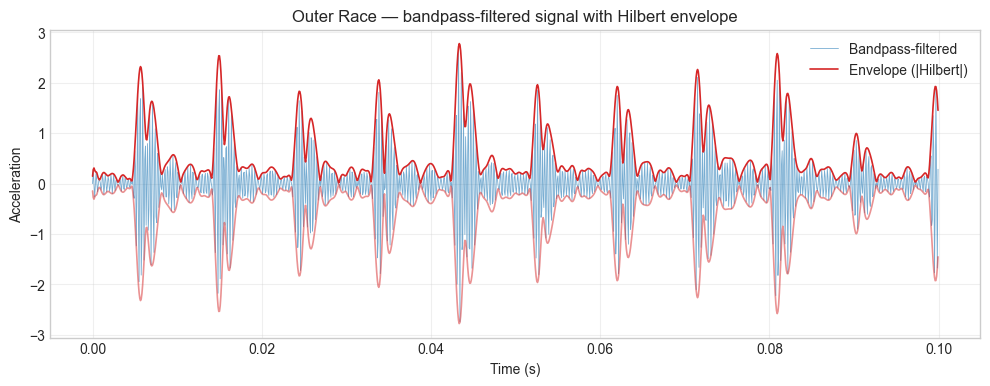

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

t = np.arange(int(0.1 * fs)) / fs
condition = 'Outer Race'

filtered = filtered_signals[condition][:len(t)]
envelope = envelopes[condition][:len(t)]

ax.plot(t, filtered, linewidth=0.6, color='tab:blue',
        alpha=0.6, label='Bandpass-filtered')
ax.plot(t, envelope, linewidth=1.2, color='tab:red',
        label='Envelope (|Hilbert|)')
ax.plot(t, -envelope, linewidth=1.2, color='tab:red',
        alpha=0.5)  # mirrored, no label

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration')
ax.set_title(f'{condition} — bandpass-filtered signal with Hilbert envelope')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.show()

In [13]:
def welch_psd(signal, fs, nperseg=4096):
    """
    Compute Welch's power spectral density estimate.

    Parameters
    ----------
    signal : ndarray
        1D time-series signal
    fs : float
        Sampling frequency in Hz
    nperseg : int
        Segment length in samples. Frequency resolution is fs/nperseg.

    Returns
    -------
    freqs : ndarray
        Frequency axis in Hz
    psd : ndarray
        Power spectral density in (signal units)^2 / Hz
    """
    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
    )
    return freqs, psd

In [14]:
envelope_psds = {}
for condition, envelope in envelopes.items():
    envelope_ac = envelope - envelope.mean()
    freqs, psd = welch_psd(envelope_ac, fs, nperseg=4096)
    envelope_psds[condition] = (freqs, psd)

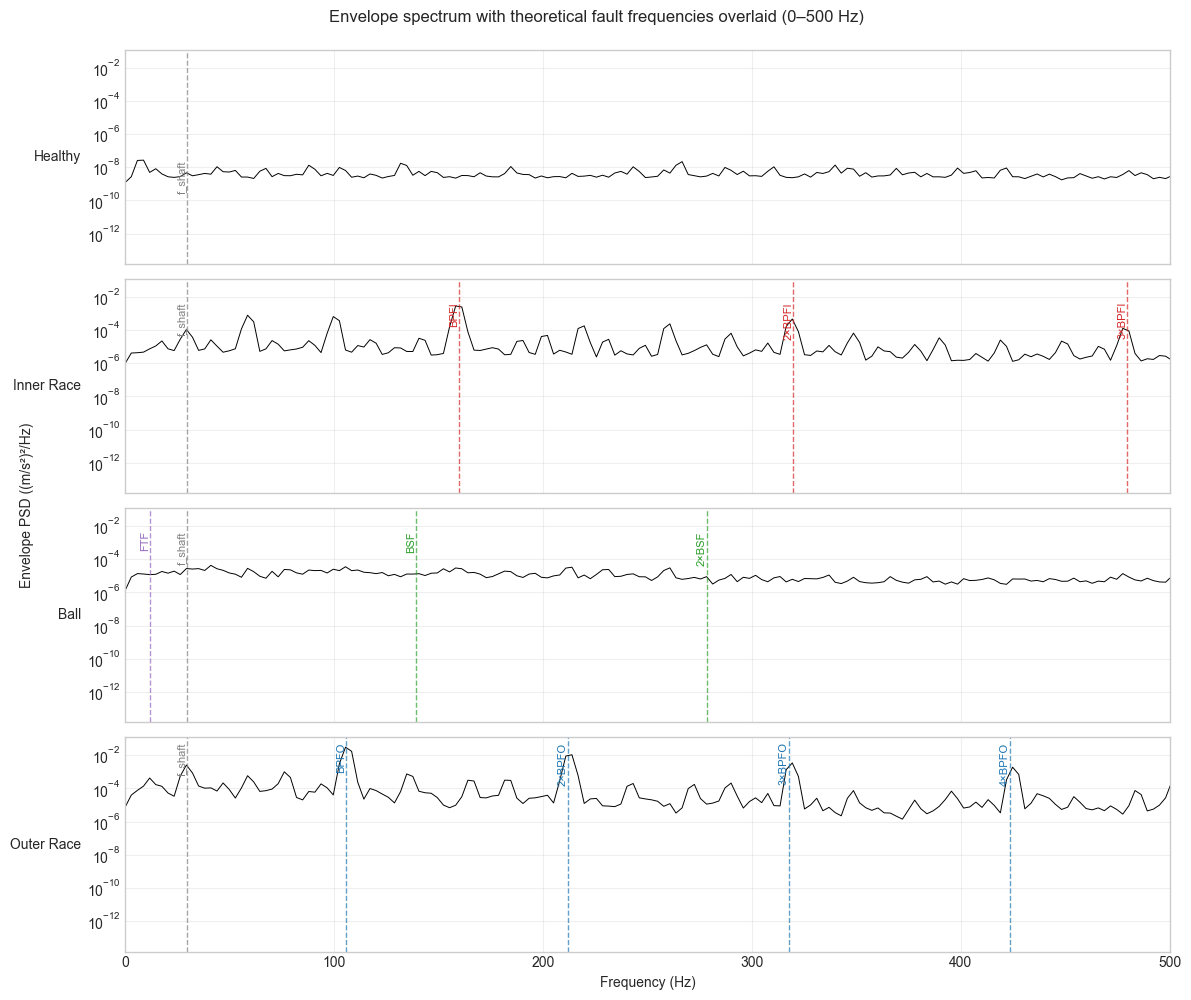

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, sharey=True)

freq_colors = {
    'f_shaft': 'gray',
    'FTF':     'tab:purple',
    'BPFI':    'tab:red',
    'BPFO':    'tab:blue',
    'BSF':     'tab:green',
}

for ax, (condition, (freqs, psd)) in zip(axes, envelope_psds.items()):
    ax.semilogy(freqs, psd, linewidth=0.7, color='black')

    for label, f in overlay_freqs[condition].items():
        base = label.split('×')[-1] if '×' in label else label
        color = freq_colors.get(base, 'gray')
        ax.axvline(f, color=color, linestyle='--', linewidth=1.0, alpha=0.7)
        ax.text(f, ax.get_ylim()[1] * 0.5, label,
                rotation=90, ha='right', va='top', fontsize=8, color=color)

    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(0, 500)
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.text(0.02, 0.5, 'Envelope PSD ((m/s²)²/Hz)', rotation=90, va='center')
fig.suptitle('Envelope spectrum with theoretical fault frequencies overlaid (0–500 Hz)',
             fontsize=12, y=0.995)
fig.tight_layout()
plt.show()

In [18]:
# Raw Welch PSD of the Outer Race signal (without bandpass or Hilbert)
raw_freqs, raw_psd = welch_psd(signals['Outer Race'], fs, nperseg=4096)

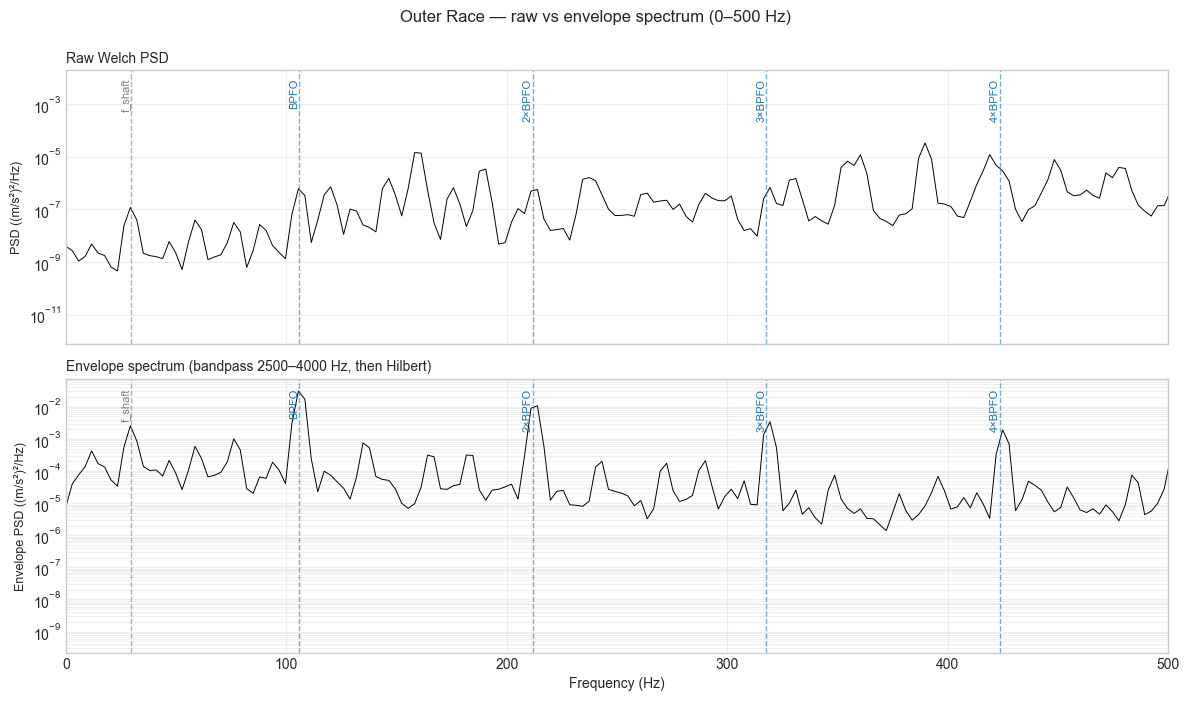

In [19]:
condition = 'Outer Race'
env_freqs, env_psd = envelope_psds[condition]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: raw Welch PSD
axes[0].semilogy(raw_freqs, raw_psd, linewidth=0.7, color='black')
axes[0].set_title('Raw Welch PSD', loc='left', fontsize=10)
axes[0].set_ylabel('PSD ((m/s²)²/Hz)', fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

# Bottom panel: envelope spectrum
axes[1].semilogy(env_freqs, env_psd, linewidth=0.7, color='black')
axes[1].set_title('Envelope spectrum (bandpass 2500–4000 Hz, then Hilbert)',
                  loc='left', fontsize=10)
axes[1].set_ylabel('Envelope PSD ((m/s²)²/Hz)', fontsize=9)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].grid(True, which='both', alpha=0.3)

# Overlay BPFO and harmonics on both panels
for label, f in overlay_freqs[condition].items():
    if 'BPFO' not in label and label != 'f_shaft':
        continue  # only mark BPFO-family and shaft frequency for clarity
    color = 'tab:blue' if 'BPFO' in label else 'gray'
    for ax in axes:
        ax.axvline(f, color=color, linestyle='--', linewidth=1.0, alpha=0.6)
        ax.text(f, ax.get_ylim()[1] * 0.5, label,
                rotation=90, ha='right', va='top', fontsize=8, color=color)

axes[0].set_xlim(0, 500)
fig.suptitle(f'{condition} — raw vs envelope spectrum (0–500 Hz)',
             fontsize=12, y=0.995)
fig.tight_layout()

fig.savefig('../figures/raw_vs_envelope_outer_race.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def peak_to_noise_ratio(freqs, psd, peak_freq, search_halfwidth_hz=20):
    """Compute peak PSD / median PSD in a band around the peak."""
    band_mask = np.abs(freqs - peak_freq) <= search_halfwidth_hz
    band_psd = psd[band_mask]
    peak_val = band_psd.max()
    # Exclude the top 20% of bins (the peak itself and its neighbours)
    noise_floor = np.median(np.sort(band_psd)[:int(0.8 * len(band_psd))])
    return peak_val / noise_floor

In [21]:
def find_fault_peak(freqs, psd, theoretical_freq, tolerance=0.05):
    """
    Find the peak in the envelope spectrum within ±tolerance of theoretical_freq.

    Parameters
    ----------
    freqs, psd : ndarrays
        Frequency axis and PSD values from welch_psd
    theoretical_freq : float
        Theoretical fault frequency in Hz
    tolerance : float
        Search half-width as a fraction of theoretical_freq (default 5%)

    Returns
    -------
    dict with keys:
        'f_theoretical' : the input theoretical frequency
        'f_measured'    : frequency of the peak bin within the search window
        'error_hz'      : f_measured - f_theoretical
        'error_pct'     : 100 * error_hz / f_theoretical
        'peak_psd'      : PSD value at the peak
        'snr_db'        : 10 * log10(peak / local noise floor)
    """
    halfwidth = tolerance * theoretical_freq
    mask = np.abs(freqs - theoretical_freq) <= halfwidth
    band_freqs = freqs[mask]
    band_psd = psd[mask]

    peak_idx = np.argmax(band_psd)
    f_measured = band_freqs[peak_idx]
    peak_psd = band_psd[peak_idx]

    error_hz = f_measured - theoretical_freq
    error_pct = 100 * error_hz / theoretical_freq

    snr = peak_to_noise_ratio(freqs, psd, theoretical_freq)
    snr_db = 10 * np.log10(snr)

    return {
        'f_theoretical': theoretical_freq,
        'f_measured':    f_measured,
        'error_hz':      error_hz,
        'error_pct':     error_pct,
        'peak_psd':      peak_psd,
        'snr_db':        snr_db,
    }

In [24]:
diagnostic_rows = []

for condition, (env_freqs, env_psd) in envelope_psds.items():
    for label, f_theory in overlay_freqs[condition].items():
        if label == 'f_shaft':
            continue  # not a fault frequency, skip
        result = find_fault_peak(env_freqs, env_psd, f_theory)
        diagnostic_rows.append({
            'Condition': condition,
            'Frequency': label,
            'Theoretical (Hz)': result['f_theoretical'],
            'Measured (Hz)':    result['f_measured'],
            'Error (Hz)':       result['error_hz'],
            'Error (%)':        result['error_pct'],
            'SNR (dB)':         result['snr_db'],
            'Detected': 'Yes' if result['snr_db'] > 6 else 'No'
        })

df_diagnostic = pd.DataFrame(diagnostic_rows)
df_diagnostic.round(2)

,Condition,Frequency,Theoretical (Hz),Measured (Hz),Error (Hz),Error (%),SNR (dB),Detected
0,Inner Race,BPFI,159.93,158.20,-1.73,-1.08,26.00,Yes
1,Inner Race,2×BPFI,319.86,319.34,-0.52,-0.16,19.72,Yes
2,Inner Race,3×BPFI,479.79,477.54,-2.25,-0.47,16.81,Yes
3,Ball,FTF,11.76,11.72,-0.04,-0.38,3.54,No
4,Ball,BSF,139.20,140.62,1.42,1.02,3.66,No
5,Ball,2×BSF,278.41,290.04,11.63,4.18,6.57,Yes
6,Outer Race,BPFO,105.87,105.47,-0.40,-0.38,26.46,Yes
7,Outer Race,2×BPFO,211.74,213.87,2.13,1.00,26.34,Yes
8,Outer Race,3×BPFO,317.61,319.34,1.72,0.54,25.34,Yes
9,Outer Race,4×BPFO,423.48,424.80,1.32,0.31,21.77,Yes
